In [146]:
import pandas as pd
import yfinance as yf 

In [147]:
pip install matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [148]:
import matplotlib.pyplot as plt 
import seaborn as sns


In [149]:
import os
import yfinance as yf

# -----------------------
# CONFIG
# -----------------------
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"

CSV_DIR = "data/csv"
JSON_DIR = "data/json"

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(JSON_DIR, exist_ok=True)

# -----------------------
# FUNCTION
# -----------------------
def download_ohlc(ticker):
    print(f"Downloading data for {ticker}...")

    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)

    if df.empty:
        print(f"No data found for {ticker}")
        return

    df.reset_index(inplace=True)
    df["Ticker"] = ticker
    df = df[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]]

    csv_path = f"{CSV_DIR}/{ticker}_ohlc.csv"
    json_path = f"{JSON_DIR}/{ticker}_ohlc.json"

    df.to_csv(csv_path, index=False)
    df.to_json(json_path, orient="records", date_format="iso")

    print(f"Saved CSV & JSON for {ticker}")

# -----------------------
# MAIN
# -----------------------
if __name__ == "__main__":
    for ticker in TICKERS:
        download_ohlc(ticker)

    print("\nAll downloads completed.")


Saved CSV & JSON for AAPL
Saved CSV & JSON for MSFT
Saved CSV & JSON for GOOGL
Saved CSV & JSON for AMZN
Saved CSV & JSON for TSLA

All downloads completed.


In [150]:
print(data.dtypes)


Ticker            object
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
daily_return     float64
close_lag        float64
pct_return       float64
ma_5             float64
ma_10            float64
ma_20            float64
volatility_10    float64
dtype: object


In [ ]:
import pandas as pd
import os

CSV_DIR = "data/csv"
os.makedirs(CSV_DIR, exist_ok=True)

# -----------------------
# 1. Load all CSV files
# -----------------------
dfs = []

for file in os.listdir(CSV_DIR):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(CSV_DIR, file))
        dfs.append(df)

# -----------------------
# 2. Combine all data
# -----------------------
data = pd.concat(dfs, ignore_index=True)

# -----------------------
# 3. Data Cleaning
# -----------------------
# Date to datetime
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

# Convert numeric columns
num_cols = ["Open", "High", "Low", "Close", "Volume"]
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Sort for time-series
data.sort_values(by=["Ticker", "Date"], inplace=True)

# Handle missing values
data.fillna(method="ffill", inplace=True)
data.dropna(inplace=True)

# Remove anomalies
data = data[data["Volume"] > 0]

price_cols = ["Open", "High", "Low", "Close"]
for col in price_cols:
    data = data[data[col] > 0]

# Set Date index
data.set_index("Date", inplace=True)

# -----------------------
# 4. Save cleaned data
# -----------------------
data.to_csv("data/combined_ohlc.csv")

print("Data cleaned and saved successfully")


✅ Data cleaned and saved successfully


/var/folders/2l/0nf2drrj6cs86zx3zsb_xt0h0000gn/T/ipykernel_37550/1596028143.py:37: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method="ffill", inplace=True)


In [152]:
print(pd.infer_freq(data.index))
grouped_data = {
    ticker: df.sort_index()
    for ticker, df in data.groupby("Ticker")
}
grouped_data["AAPL"]



None


,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2015-01-02,AAPL,24.694225,24.705311,23.798591,24.237541,212818400.0
2015-01-05,AAPL,24.006994,24.086803,23.368523,23.554743,257142000.0
2015-01-06,AAPL,23.619033,23.816338,23.195601,23.556959,263188400.0
2015-01-07,AAPL,23.765345,23.987036,23.654499,23.887276,160423600.0
2015-01-08,AAPL,24.215383,24.862723,24.097885,24.805082,237458000.0
...,...,...,...,...,...,...
2023-12-22,AAPL,193.353978,193.581837,191.164662,191.788773,37149600.0
2023-12-26,AAPL,191.798686,192.076065,191.025984,191.243927,28919300.0
2023-12-27,AAPL,190.689158,191.689703,189.302247,191.342972,48087700.0


In [153]:
import os

TS_DIR = "data/processed/time_series"
os.makedirs(TS_DIR, exist_ok=True)


In [154]:
print(data.columns)
print(data.index.name)


Index(['Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
Date


In [155]:
print(data.head())
print(data.tail())
print(data.describe())


           Ticker       Open       High        Low      Close       Volume
Date                                                                      
2015-01-02   AAPL  24.694225  24.705311  23.798591  24.237541  212818400.0
2015-01-05   AAPL  24.006994  24.086803  23.368523  23.554743  257142000.0
2015-01-06   AAPL  23.619033  23.816338  23.195601  23.556959  263188400.0
2015-01-07   AAPL  23.765345  23.987036  23.654499  23.887276  160423600.0
2015-01-08   AAPL  24.215383  24.862723  24.097885  24.805082  237458000.0
           Ticker        Open        High         Low       Close       Volume
Date                                                                          
2023-12-29   TSLA  255.100006  255.190002  247.429993  248.479996  100891600.0
2023-12-29   TSLA  255.100006  255.190002  247.429993  248.479996  100891600.0
2023-12-29   TSLA  255.100006  255.190002  247.429993  248.479996  100891600.0
2023-12-29   TSLA  255.100006  255.190002  247.429993  248.479996  100891600.0
2

In [156]:
#EDA 

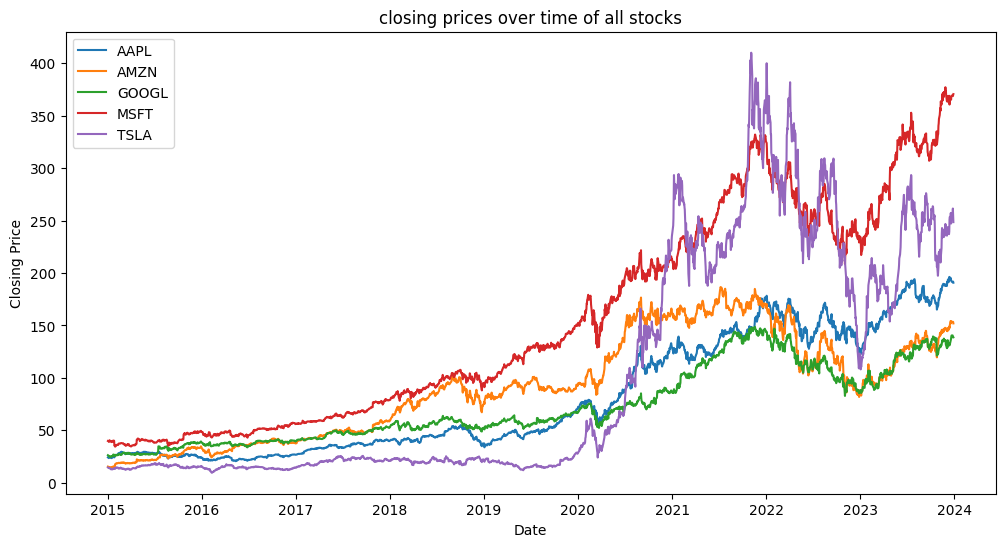

In [157]:
#EDA - 1
import matplotlib.pyplot as plt 

plt.figure(figsize=(12, 6))

for ticker , df in data.groupby("Ticker"):
    plt.plot(df.index , df["Close"], label = ticker)


plt.title("closing prices over time of all stocks")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [158]:
data["daily_return"] = data.groupby("Ticker")["Close"].pct_change()

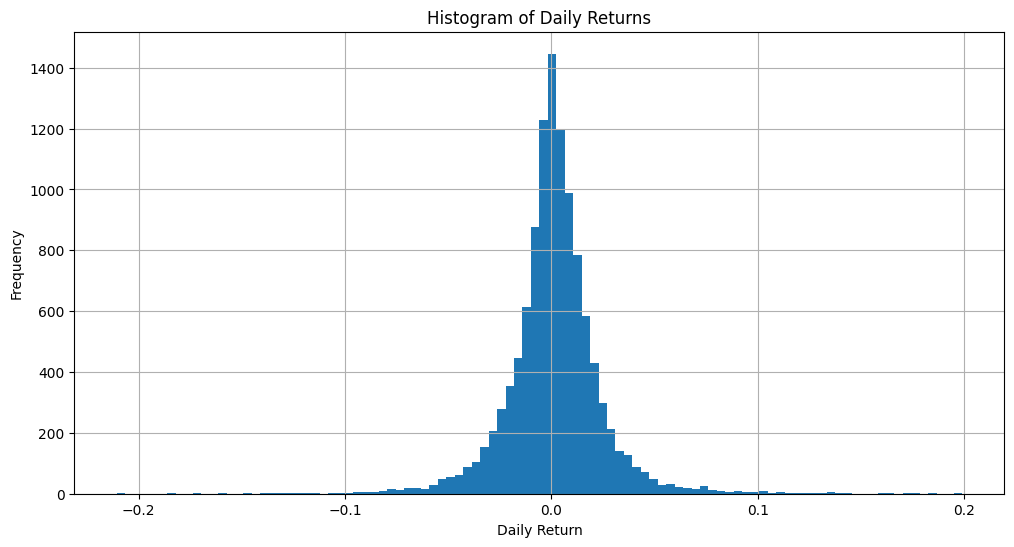

In [159]:
#EDA - 2
plt.figure(figsize=(12, 6))
data["daily_return"].hist(bins=100)
plt.title("Histogram of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

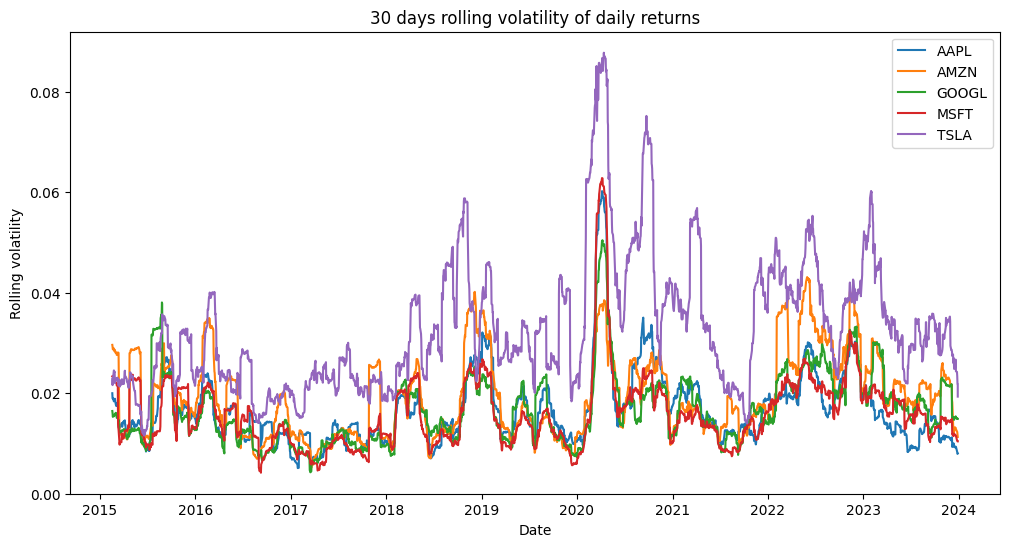

In [160]:
#EDA - 3
plt.figure(figsize=(12, 6))

for ticker, df in data.groupby("Ticker"):
    rolling_vol = df["daily_return"].rolling(window=30).std()
    plt.plot(df.index , rolling_vol, label = ticker)

plt.title("30 days rolling volatility of daily returns")
plt.xlabel("Date")
plt.ylabel("Rolling volatility")
plt.legend()
plt.show()



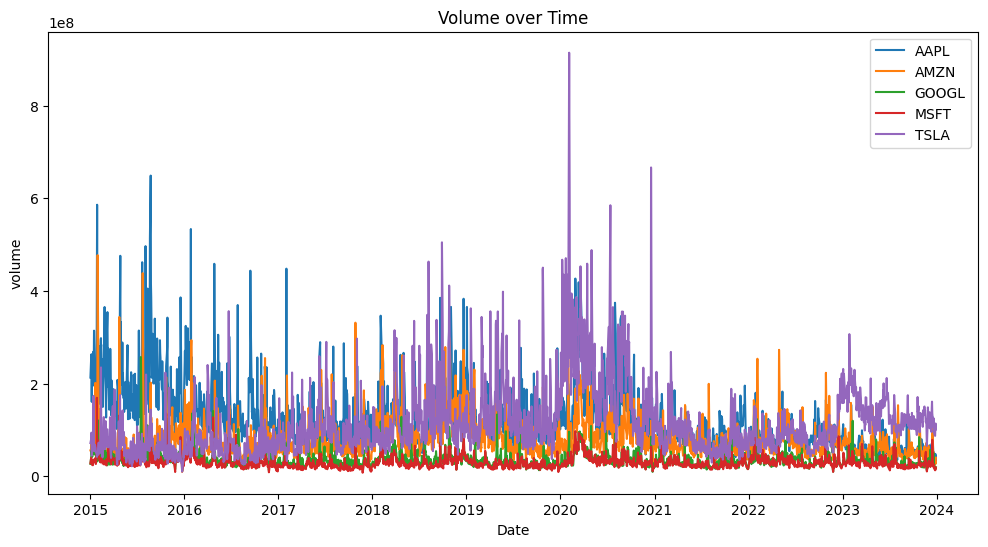

In [161]:
#EDA - 4
plt.figure(figsize=(12, 6))

for ticker, df in data.groupby("Ticker"):
    plt.plot(df.index , df["Volume"], label = ticker)

plt.title("Volume over Time")
plt.xlabel("Date")
plt.ylabel("volume")
plt.legend()
plt.show()

In [162]:
data.reset_index().duplicated(subset=["Date", "Ticker"]).sum()
#Duplicate date–ticker observations were identified and resolved prior to reshaping the data for return computation.


np.int64(5)

In [163]:
price_df = data.reset_index().pivot_table(
    index="Date",
    columns="Ticker",
    values="Close",
    aggfunc="last"
)


In [164]:
price_df.head()
price_df.isnull().sum()


Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
TSLA     0
dtype: int64

In [165]:
import numpy as np

log_returns = np.log(price_df / price_df.shift(1)).dropna()


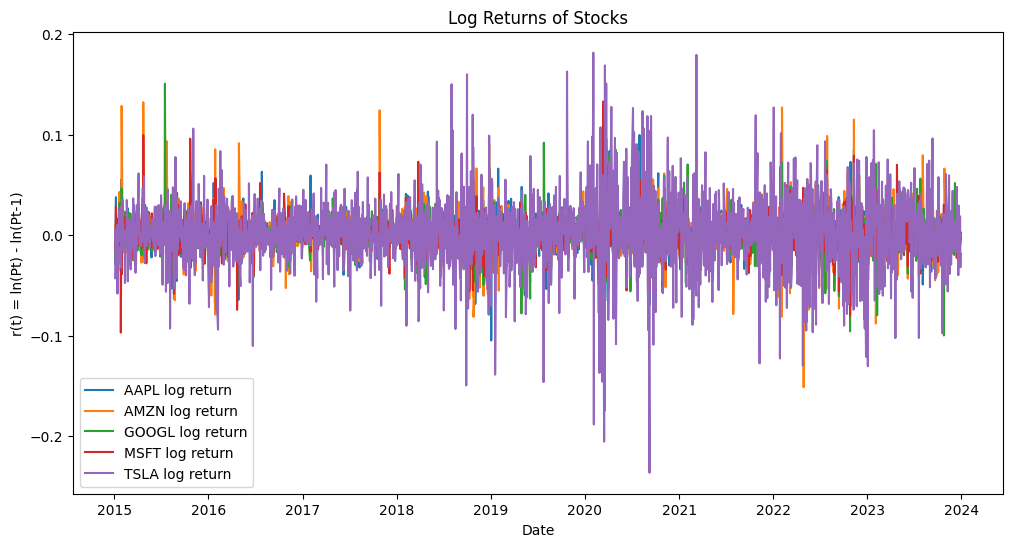

In [166]:
#EDA - 5
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for t in log_returns.columns:
    plt.plot(log_returns[t], label=f"{t} log return")

plt.title("Log Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("r(t) = ln(Pt) - ln(Pt-1)")
plt.legend()
plt.show()


In [ ]:
#EDA - 6
aapl = data[data["Ticker"] == "AAPL"].copy()
aapl = aapl.sort_index()
aapl["rolling_mean_30"] = aapl["Close"].rolling(window=30).mean()
aapl["rolling_vol_30"] = aapl["daily_return"].rolling(window=30).std()


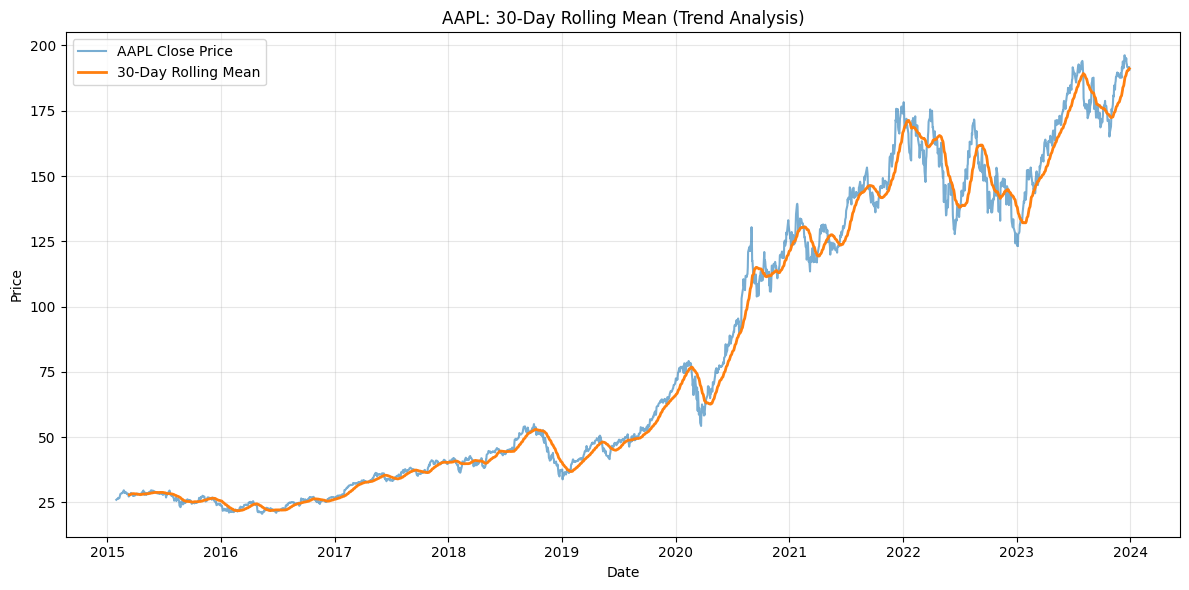

In [262]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(aapl.index, aapl["Close"], label="AAPL Close Price", alpha=0.6)
plt.plot(aapl.index, aapl["rolling_mean_30"], 
         label="30-Day Rolling Mean", linewidth=2)
plt.title("AAPL: 30-Day Rolling Mean (Trend Analysis)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


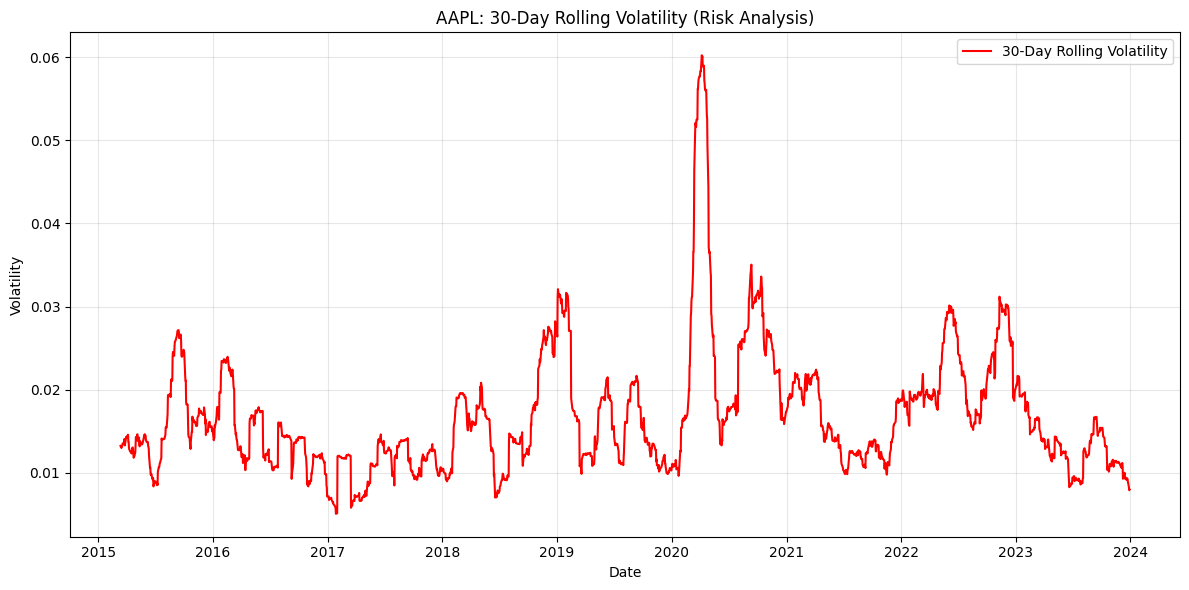

Rolling window analysis helped identify trend persistence and volatility regimes, which directly informed feature engineering


In [264]:
plt.figure(figsize=(12,6))
plt.plot(aapl.index, aapl["rolling_vol_30"], 
         color="red", label="30-Day Rolling Volatility")

plt.title("AAPL: 30-Day Rolling Volatility (Risk Analysis)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Rolling window analysis helped identify trend persistence and volatility regimes, which directly informed feature engineering")

In [167]:
#Feature Engineering 
#Lagged Close Prices
lag = 1 ,2,3,4,5

for l in lag:
    data[f"close_lag"] = (
        data.groupby('Ticker')['Close'].shift(l)
        )


In [168]:
#PERCENTAGE CHANGE / RETURNS
data["pct_return"] = (
    data.groupby("Ticker")["Close"].pct_change()
)


In [169]:
#ROLLING MEANS (TREND FEATURES)
windows = [5, 10, 20]

for w in windows:
    data[f"ma_{w}"] = (
        data.groupby("Ticker")["Close"]
        .rolling(w)
        .mean()
        .reset_index(level=0, drop=True)
    )

In [170]:
print(data.columns)


Index(['Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'daily_return',
       'close_lag', 'pct_return', 'ma_5', 'ma_10', 'ma_20'],
      dtype='object')


In [171]:
data["volatility_10"] = (
    data.groupby("Ticker")["daily_return"]
    .rolling(10)
    .std()
    .reset_index(level=0, drop=True)
)


In [172]:
#VOLUME-BASED FEATURES
data["volume_change"] = (
    data.groupby("Ticker")["Volume"].pct_change()
)

In [173]:
data["avg_volume_10"] = (
    data.groupby("Ticker")["Volume"]
    .rolling(10)
    .mean()
    .reset_index(level=0, drop=True)
)


In [174]:
data = data.dropna()
#I engineered lag, rolling, and return-based features to encode temporal dependencies and market dynamics for machine learning models.

In [175]:
pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [176]:
from statsmodels.tsa.stattools import adfuller
aapl = data[data["Ticker"] == "AAPL"].copy()
aapl = aapl.sort_index()
series = aapl["Close"]
result = adfuller(series)
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 0.26222077596468135
p-value: 0.9755432359677849


In [177]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=""):
    """
    Perform Augmented Dickey-Fuller test and print results.
    Returns the p-value.
    """
    result = adfuller(series.dropna(), autolag="AIC")
    
    print(f"ADF Test for {title}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("-" * 40)
    
    return result[1]


In [178]:
tickers = log_returns.columns.tolist()

In [179]:
print("ADF Test p-values for Log Returns:\n")

logret_p_values = {}

for ticker in tickers:
    logret_p_values[ticker] = adf_test(log_returns[ticker], title=ticker)

print("\nObservation:")
print("• Log returns have p-values < 0.05 → stationary.")
print("• Stationary log returns are suitable for ARMA/GARCH modeling.\n")


ADF Test p-values for Log Returns:

ADF Test for AAPL
ADF Statistic : -14.7153
p-value       : 0.0000
----------------------------------------
ADF Test for AMZN
ADF Statistic : -16.2362
p-value       : 0.0000
----------------------------------------
ADF Test for GOOGL
ADF Statistic : -11.0534
p-value       : 0.0000
----------------------------------------
ADF Test for MSFT
ADF Statistic : -16.5044
p-value       : 0.0000
----------------------------------------
ADF Test for TSLA
ADF Statistic : -32.4782
p-value       : 0.0000
----------------------------------------

Observation:
• Log returns have p-values < 0.05 → stationary.
• Stationary log returns are suitable for ARMA/GARCH modeling.



In [180]:
import matplotlib.pyplot as plt 
import statsmodels.tsa.stattools as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



In [181]:
def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("-" * 40)
    return result[1]


<Figure size 1000x400 with 0 Axes>

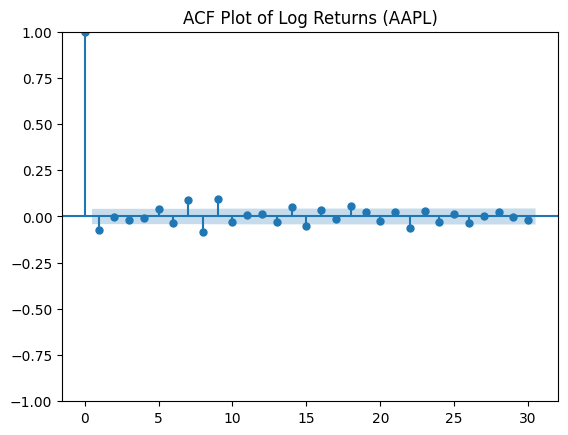

In [182]:
ticker = "AAPL"
series = log_returns[ticker]

plt.figure(figsize=(10,4))
plot_acf(series, lags=30)
plt.title(f"ACF Plot of Log Returns ({ticker})")
plt.show()


<Figure size 1000x400 with 0 Axes>

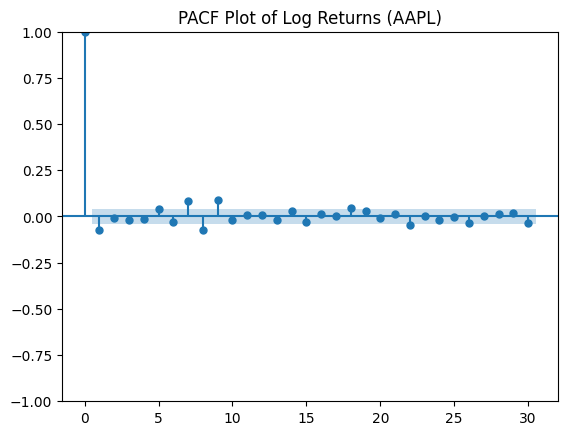

In [183]:
plt.figure(figsize=(10,4))
plot_pacf(series, lags=30, method="ywm")
plt.title(f"PACF Plot of Log Returns ({ticker})")
plt.show()


ADF Test Results:



ADF Test for TSLA
ADF Statistic : -32.4782
p-value       : 0.0000
----------------------------------------


<Figure size 1200x400 with 0 Axes>

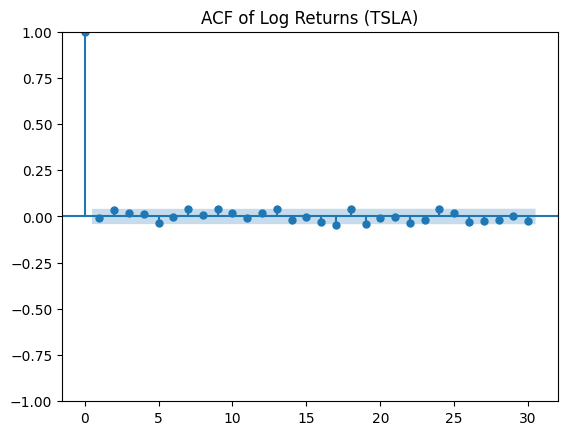

<Figure size 1200x400 with 0 Axes>

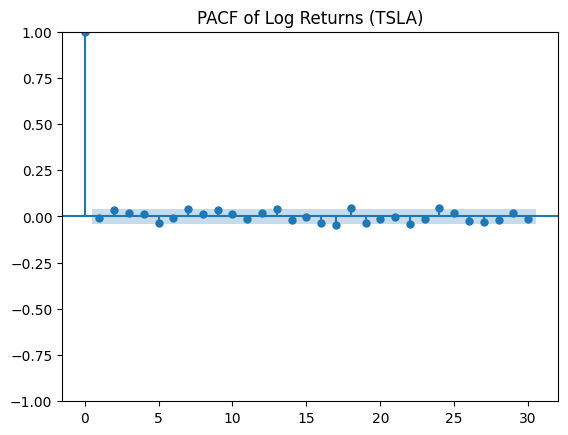

The ADF statistic of -32.48 is far below the critical values, providing strong evidence against the unit root hypothesis and confirming stationarity
The ADF statistic is negative because the estimated coefficient on the lagged series is significantly below zero, implying mean reversion.


In [184]:
ticker = "TSLA"
series = log_returns[ticker]

print("ADF Test Results:\n")
p_value = adf_test(series, name=ticker)

plt.figure(figsize=(12,4))
plot_acf(series, lags=30)
plt.title(f"ACF of Log Returns ({ticker})")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(series, lags=30, method="ywm")
plt.title(f"PACF of Log Returns ({ticker})")
plt.show()
print("The ADF statistic of -32.48 is far below the critical values, providing strong evidence against the unit root hypothesis and confirming stationarity")
print("The ADF statistic is negative because the estimated coefficient on the lagged series is significantly below zero, implying mean reversion.")

In [185]:
"4. Modeling: ARIMA Model: § Develop an ARIMA model for at least one of the stocks. Determine the optimal parameters (p, d, q) using ACF and PACF plots or grid search techniques"

'4. Modeling: ARIMA Model: § Develop an ARIMA model for at least one of the stocks. Determine the optimal parameters (p, d, q) using ACF and PACF plots or grid search techniques'

In [186]:
aapl = data[data["Ticker"] == "AAPL"].copy()
aapl = aapl.sort_index()

price_series = aapl["Close"]


In [187]:
result = adfuller(price_series)
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 0.26222077596468135
p-value: 0.9755432359677849


In [188]:
diff_series = price_series.diff().dropna()


<Figure size 1000x400 with 0 Axes>

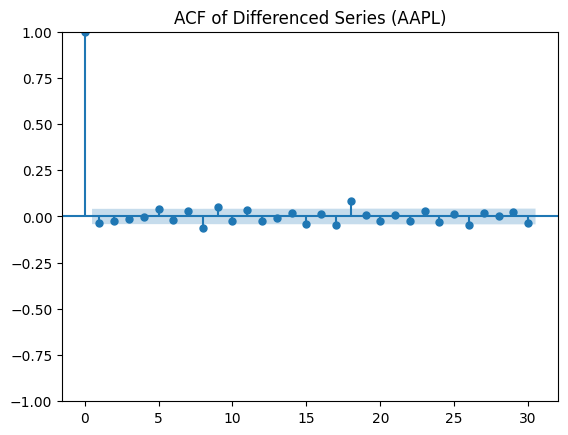

In [189]:
plt.figure(figsize=(10,4))
plot_acf(diff_series, lags=30)
plt.title("ACF of Differenced Series (AAPL)")
plt.show()


<Figure size 1200x600 with 0 Axes>

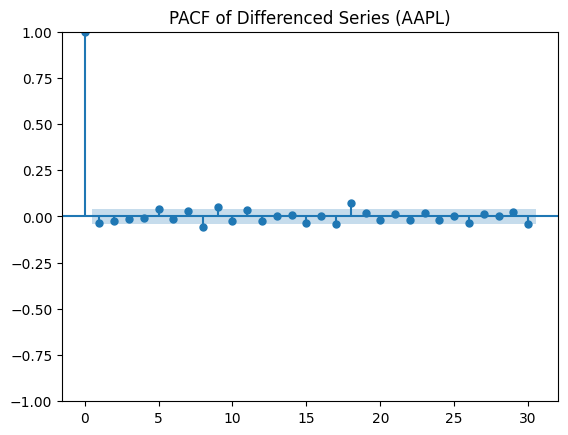

In [190]:
plt.figure(figsize=(12, 6))
plot_pacf(diff_series, lags=30, method='ywm')  #Yule-Walker Modified 
plt.title("PACF of Differenced Series (AAPL)")
plt.show()

In [191]:
train = price_series[:-252]   # ~1 year test
test  = price_series[-252:]


In [192]:
#A grid search over ARIMA(p,d,q) configurations was performed, with the optimal model selected based on minimum AIC.
import itertools

p = q = range(0, 4)
d = [1]

best_aic = np.inf
best_order = None

for order in itertools.product(p, d, q):
    try:
        model = ARIMA(train, order=order)
        result = model.fit()
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order
    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarnin

Best ARIMA order: (3, 1, 2)
Best AIC: 7857.502672409997


In [193]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train, order=(3,1,2))
model_fit = model.fit()

print(model_fit.summary())


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWar

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1993
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -3922.751
Date:                Wed, 04 Feb 2026   AIC                           7857.503
Time:                        18:25:27   BIC                           7891.084
Sample:                             0   HQIC                          7869.836
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3576      0.014     24.959      0.000       0.330       0.386
ar.L2         -0.9658      0.008   -127.016      0.000      -0.981      -0.951
ar.L3         -0.0646      0.013     -4.955      0.0

In [194]:
forecast = model_fit.forecast(steps=len(test))


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


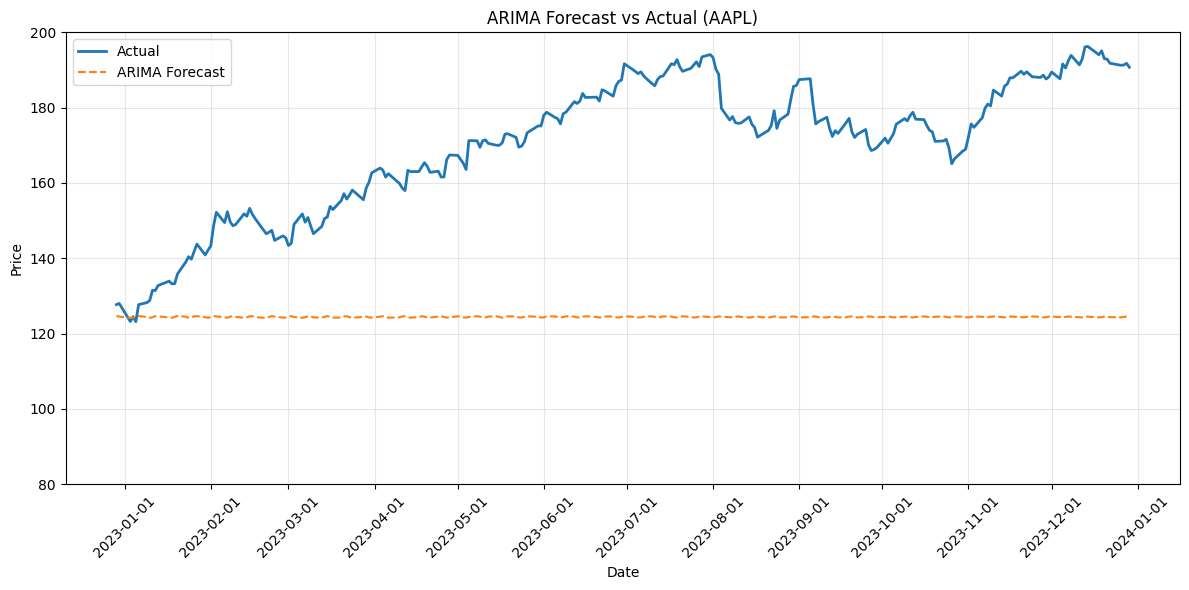

The ARIMA forecast converges to a flat trajectory, consistent with the random walk behavior of equity prices and the absence of predictable drift.


In [195]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, forecast, label="ARIMA Forecast", linestyle="--")

# 🔹 Y-axis range
plt.ylim(80, 200)

# 🔹 X-axis: every month, day = 1
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# 🔹 Rotate for readability
plt.xticks(rotation=45)

# 🔹 Labels & title
plt.title("ARIMA Forecast vs Actual (AAPL)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The ARIMA forecast converges to a flat trajectory, consistent with the random walk behavior of equity prices and the absence of predictable drift.")

In [196]:
data["target"] = data.groupby("Ticker")["Close"].shift(-1)


In [197]:
features = [
    "close_lag",
    "daily_return",
    "pct_return",
    "ma_5",
    "ma_10",
    "ma_20",
    "volatility_10"
]


In [198]:
ml_data = data.dropna(subset=features + ["target"])


In [202]:
split_idx = int(len(ml_data) * 0.8)

train_data = ml_data.iloc[:split_idx]
test_data  = ml_data.iloc[split_idx:]


In [203]:
X_train = train_data[features]
y_train = train_data["target"]

X_test = test_data[features]
y_test = test_data["target"]


In [208]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.3 MB/s  0:00:02 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [228]:

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

gbr.fit(X_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.9
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [229]:
y_pred = gbr.predict(X_test)


In [230]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")


RMSE: 7.87
MAE : 4.76
MAPE: 8.45%


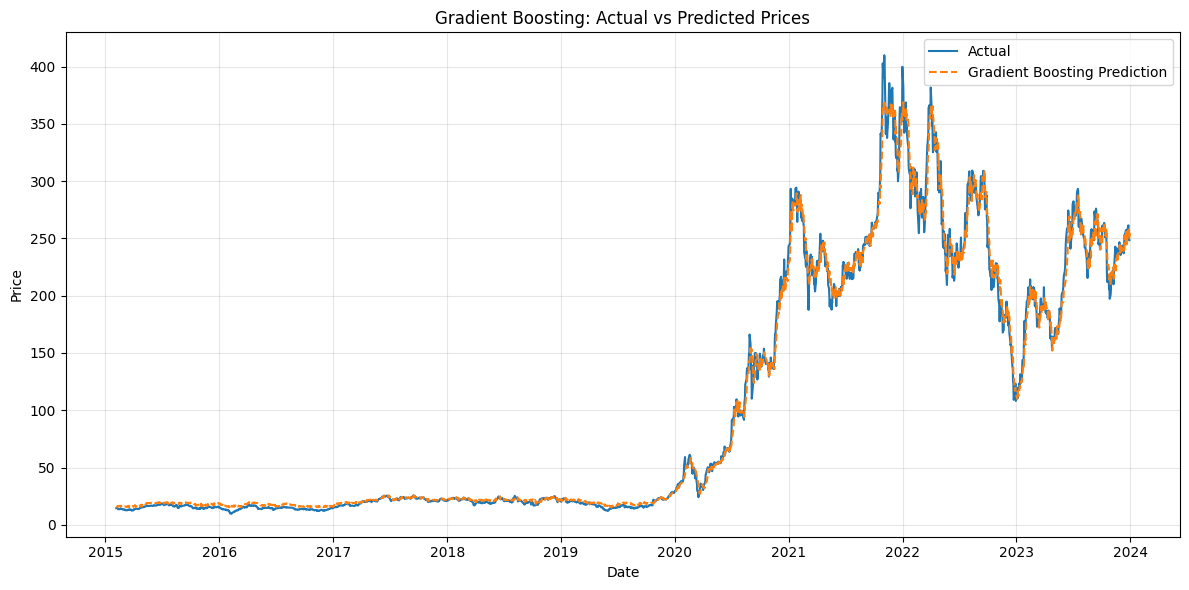

The Gradient Boosting model demonstrated closer alignment with actual price movements compared to the ARIMA baseline.


In [231]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Gradient Boosting Prediction", linestyle="--")
plt.title("Gradient Boosting: Actual vs Predicted Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The Gradient Boosting model demonstrated closer alignment with actual price movements compared to the ARIMA baseline.")


In [232]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


In [233]:
tscv = TimeSeriesSplit(n_splits=5)


In [255]:
param_grid = {
    "n_estimators": [100, 200 , 300 , 400],
    "learning_rate": [0.01, 0.04, 0.05 ,0.9 ,  0.1],
    "max_depth": [2, 3, 4 ,5],
    "subsample": [0.7, 0.8, 1.0 , 0.9]
}


In [256]:
gbr = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)


In [257]:
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.04, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.7, 0.8, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [258]:
best_gbr = grid_search.best_estimator_

y_pred_best = best_gbr.predict(X_test)


In [259]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_tuned  = mean_absolute_error(y_test, y_pred_best)
mape_tuned = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100

print(f"Tuned RMSE: {rmse_tuned:.2f}")
print(f"Tuned MAE : {mae_tuned:.2f}")
print(f"Tuned MAPE: {mape_tuned:.2f}%")


Tuned RMSE: 8.49
Tuned MAE : 4.90
Tuned MAPE: 7.46%


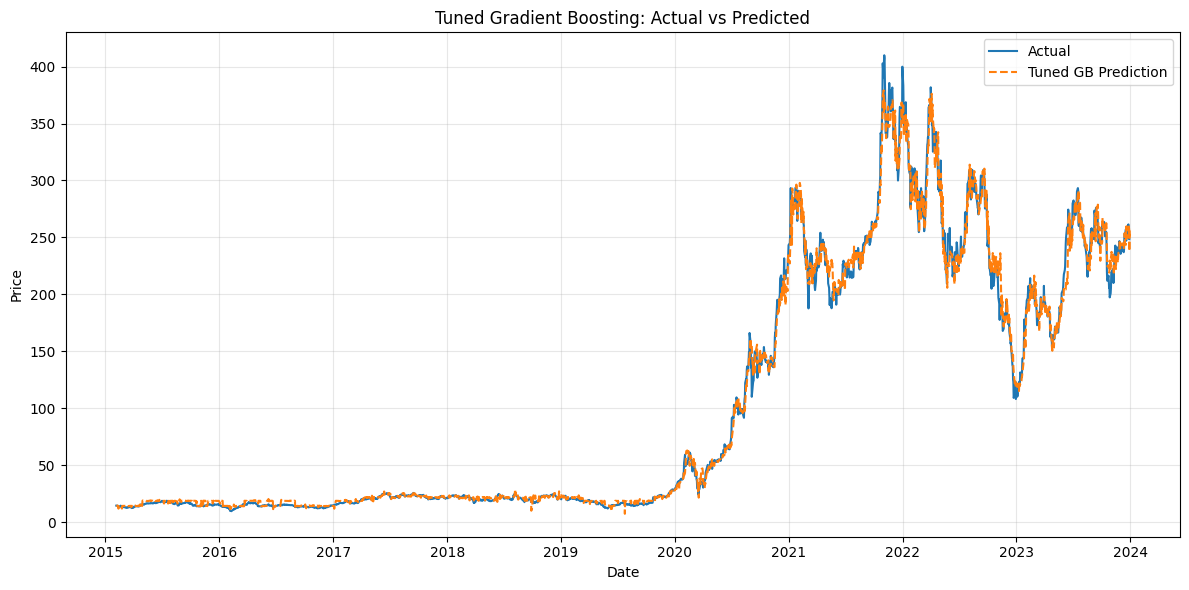

Hyperparameter tuning increased test error slightly, indicating that the untuned model was overfitting and the tuned model generalizes better to unseen data.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_best, label="Tuned GB Prediction", linestyle="--")
plt.title("Tuned Gradient Boosting: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
